### Imports

In [1]:
import numpy as np
from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.options.simulation_options import SimulationOptions
from kwave.options.simulation_execution_options import SimulationExecutionOptions
from kwave.utils.signals import tone_burst
import matplotlib.pyplot as plt

# Tests

### 01_water_baseline

k-Wave: 100%|██████████| 604/604 [00:01<00:00, 373.91step/s]


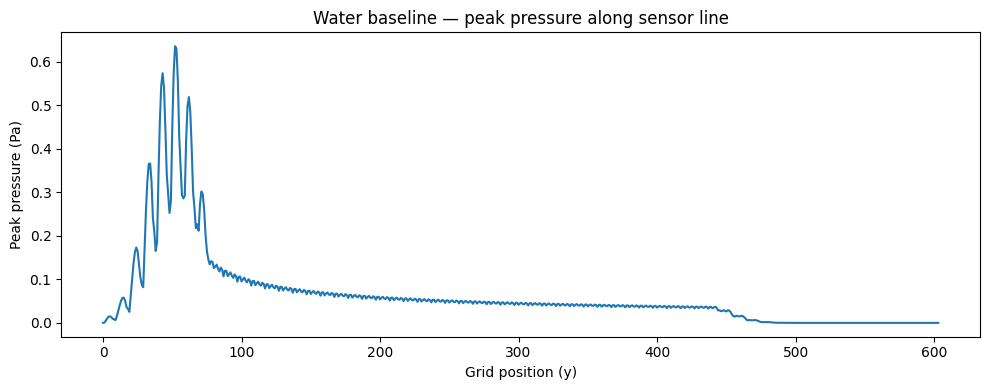

Max pressure: 0.64 Pa


In [4]:
# --- Parameters (Mueller et al. 500 kHz setup) ---
freq = 500e3          # 500 kHz
c0 = 1482.0           # speed of sound in water (m/s)
rho0 = 1000.0         # density of water (kg/m^3)

# --- Grid setup ---
wavelength = c0 / freq          # ~3 mm
dx = wavelength / 6             # 6 points per wavelength
Nx = 128
Ny = 128

kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)

# --- Medium (pure water) ---
medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Source ---
source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[Nx // 2, 10] = 1
source.p = tone_burst(1/kgrid.dt, freq, 5)

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.zeros((Nx, Ny))
sensor.mask[Nx // 2, :] = 1

# --- Run ---
sim_options = SimulationOptions(
    save_to_disk=True,
    save_to_disk_exit=False,
    data_cast='single'
)
execution_options = SimulationExecutionOptions(is_gpu_simulation=False)

sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor)

# --- Plot ---
# Replace the plot section with this:
plt.figure(figsize=(10, 4))
p_max = np.max(np.abs(sensor_data['p']), axis=0)
plt.plot(p_max)
plt.xlabel('Grid position (y)')
plt.ylabel('Peak pressure (Pa)')
plt.title('Water baseline — peak pressure along sensor line')
plt.tight_layout()
plt.savefig('01_water_baseline.png')
plt.show()
print(f"Max pressure: {np.max(p_max):.2f} Pa")

### 02_focused_transducer

Grid size: 256 x 256, dt=1.00e-07s, Nt=1207
Number of source elements: 60
Burst length: 101 samples
Running simulation...


k-Wave: 100%|████████████████████████████████████████████████████████████████████| 1207/1207 [01:54<00:00, 10.53step/s]


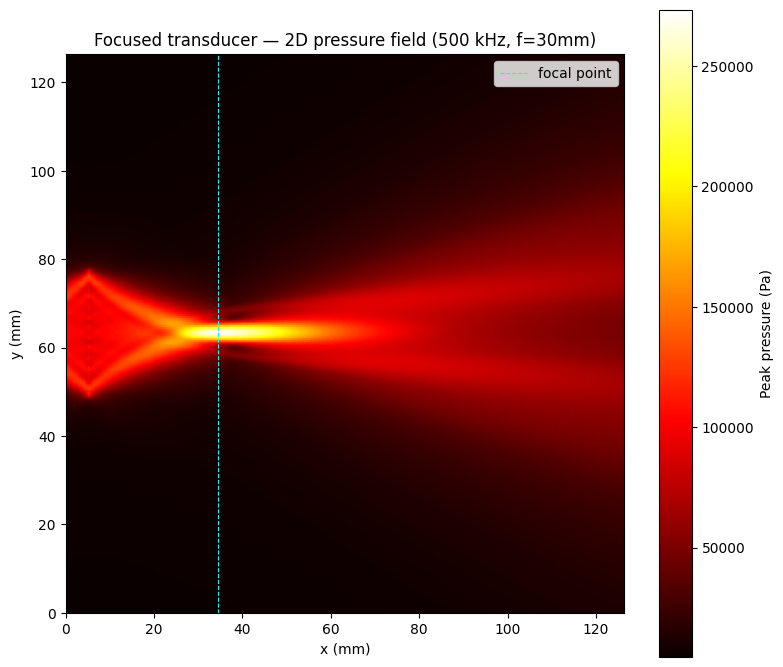

Max pressure: 273436.6 Pa
Done! Saved to 02_focused_transducer.png


: 

In [ ]:
# --- Parameters ---
freq  = 500e3
c0    = 1482.0
rho0  = 1000.0

# --- Grid ---
wavelength = c0 / freq
dx = wavelength / 6
Nx, Ny = 256, 256
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)
n_time = kgrid.Nt

# --- Medium ---
medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Transducer geometry ---
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources = len(source_y_indices)

print(f"Grid size: {Nx} x {Ny}, dt={kgrid.dt:.2e}s, Nt={n_time}")
print(f"Number of source elements: {n_sources}")

# --- Build base tone burst ---
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()
print(f"Burst length: {len(burst)} samples")

# Make sure n_time is long enough for burst + max delay
focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)  # +3.5mm correction
focal_point_y = center_y

# Compute delays
delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0

# Normalize so max delay fires first (converging focus)
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

# Ensure time array is long enough
n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
    print(f"Extended n_time to {n_time}")

# --- Build source signals ---
source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    source_signals[i, d:d + len(burst)] = burst * 1e5

# Rebuild kgrid time with correct n_time
kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# --- Run ---
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor)

# --- Plot ---
p_max = sensor_data['p_max'].reshape(Nx, Ny)

plt.figure(figsize=(8, 7))
plt.imshow(p_max.T, aspect='equal',
           extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
           origin='lower', cmap='hot')
plt.colorbar(label='Peak pressure (Pa)')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Focused transducer — 2D pressure field (500 kHz, f=30mm)')
plt.axvline(x=(transducer_x + int(focal_length/dx)) * dx * 1e3,
            color='cyan', linestyle='--', linewidth=0.8, label='focal point')
plt.legend()
plt.tight_layout()
plt.savefig('02_focused_transducer.png', dpi=150)
plt.show()
print(f"Max pressure: {np.max(p_max):.1f} Pa")
print("Done! Saved to 02_focused_transducer.png")

### 03_validate

Running simulation...


k-Wave: 100%|████████████████████████████████████████████████████████████████████| 1207/1207 [01:43<00:00, 11.70step/s]



=== VALIDATION ===

[1] Focal position
    Expected x: 34.6 mm
    Actual peak x: 34.6 mm
    Offset: 0.0 mm

[2] Beamwidth (FWHM)
    Simulated FWHM: 3.5 mm
    Mueller et al.: ~4-6 mm
    Match: YES

[3] Peak pressure at focus
    Simulated: 273 kPa
    Input source: 100 kPa
    Gain from focusing: 2.7x
    Mueller et al. (scaled to 1030 kPa): would need 3.8x more input


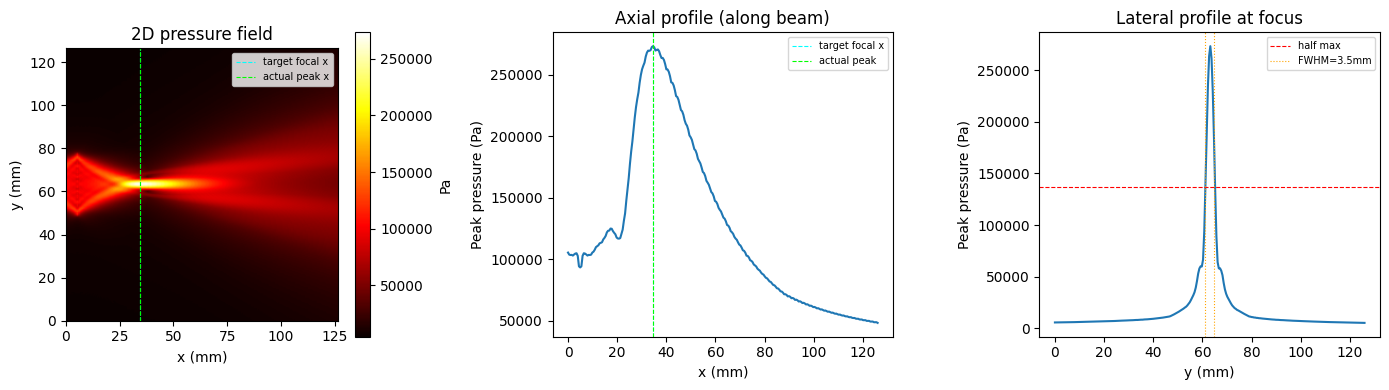


Saved to 03_validate.png


: 

In [ ]:
# --- Same parameters as 02 ---
freq         = 500e3
c0           = 1482.0
rho0         = 1000.0
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10

wavelength = c0 / freq
dx = wavelength / 6
Nx, Ny = 256, 256

kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)
n_time = kgrid.Nt

medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Source (identical to 02) ---
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources    = len(source_y_indices)

focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)  # +3.5mm correction
focal_point_y = center_y

burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    source_signals[i, d:d + len(burst)] = burst * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor)
p_max = sensor_data['p_max'].reshape(Nx, Ny)

# --- Validation ---
print("\n=== VALIDATION ===")

# 1. Where is the actual peak?
peak_idx = np.unravel_index(np.argmax(p_max), p_max.shape)
peak_x_mm = peak_idx[0] * dx * 1e3
peak_y_mm = peak_idx[1] * dx * 1e3
expected_x_mm = (transducer_x + int(focal_length / dx)) * dx * 1e3
print(f"\n[1] Focal position")
print(f"    Expected x: {expected_x_mm:.1f} mm")
print(f"    Actual peak x: {peak_x_mm:.1f} mm")
print(f"    Offset: {abs(peak_x_mm - expected_x_mm):.1f} mm")

# 2. Beamwidth (FWHM) at focal plane
focal_profile = p_max[peak_idx[0], :]   # lateral slice at peak x
half_max = np.max(focal_profile) / 2
above_half = np.where(focal_profile >= half_max)[0]
if len(above_half) > 1:
    fwhm_mm = (above_half[-1] - above_half[0]) * dx * 1e3
else:
    fwhm_mm = 0
print(f"\n[2] Beamwidth (FWHM)")
print(f"    Simulated FWHM: {fwhm_mm:.1f} mm")
print(f"    Mueller et al.: ~4-6 mm")
print(f"    Match: {'YES' if 2 < fwhm_mm < 8 else 'CHECK'}")

# 3. Peak pressure
peak_pa  = np.max(p_max)
peak_kpa = peak_pa / 1e3
print(f"\n[3] Peak pressure at focus")
print(f"    Simulated: {peak_kpa:.0f} kPa")
print(f"    Input source: 100 kPa")
print(f"    Gain from focusing: {peak_kpa/100:.1f}x")
print(f"    Mueller et al. (scaled to 1030 kPa): would need {1030/peak_kpa:.1f}x more input")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: 2D field
ax = axes[0]
im = ax.imshow(p_max.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot')
ax.axvline(x=expected_x_mm, color='cyan', linestyle='--', lw=0.8, label='target focal x')
ax.axvline(x=peak_x_mm,     color='lime', linestyle='--', lw=0.8, label='actual peak x')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('2D pressure field')
ax.legend(fontsize=7)
plt.colorbar(im, ax=ax, label='Pa')

# Plot 2: Axial profile (along beam axis, through center)
ax = axes[1]
axial = p_max[:, center_y]
x_mm  = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, axial)
ax.axvline(x=expected_x_mm, color='cyan', linestyle='--', lw=0.8, label='target focal x')
ax.axvline(x=peak_x_mm,     color='lime', linestyle='--', lw=0.8, label='actual peak')
ax.set_xlabel('x (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile (along beam)')
ax.legend(fontsize=7)

# Plot 3: Lateral profile (FWHM)
ax = axes[2]
y_mm = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, focal_profile)
ax.axhline(y=half_max, color='red', linestyle='--', lw=0.8, label=f'half max')
ax.axvline(x=above_half[0]*dx*1e3,  color='orange', linestyle=':', lw=0.8)
ax.axvline(x=above_half[-1]*dx*1e3, color='orange', linestyle=':', lw=0.8, label=f'FWHM={fwhm_mm:.1f}mm')
ax.set_xlabel('y (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Lateral profile at focus')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('03_validate.png', dpi=150)
plt.show()
print("\nSaved to 03_validate.png")

### 04_skull_layer
Flat, infite length skull layer

dt=5.11e-08s, Nt=1207
Skull: x=24.7mm to 27.7mm
Burst length: 196 samples
Running with skull...


k-Wave: 100%|████████████████████████████████████████████████████████████████████| 1207/1207 [01:53<00:00, 10.64step/s]


Skull sim OK — max pressure: 746.8 kPa
Running water baseline...


k-Wave: 100%|████████████████████████████████████████████████████████████████████| 1207/1207 [01:45<00:00, 11.40step/s]


Water sim OK — max pressure: 274.4 kPa

=== SKULL VALIDATION ===
Peak pressure (water, post-skull):      274.4 kPa
Peak pressure (with skull, post-skull): 189.5 kPa
Transmission:               69.0%
Pressure loss:              31.0%
Mueller et al. expected:    ~65% transmission (35% loss)

Theoretical transmission (impedance only): 66.8%


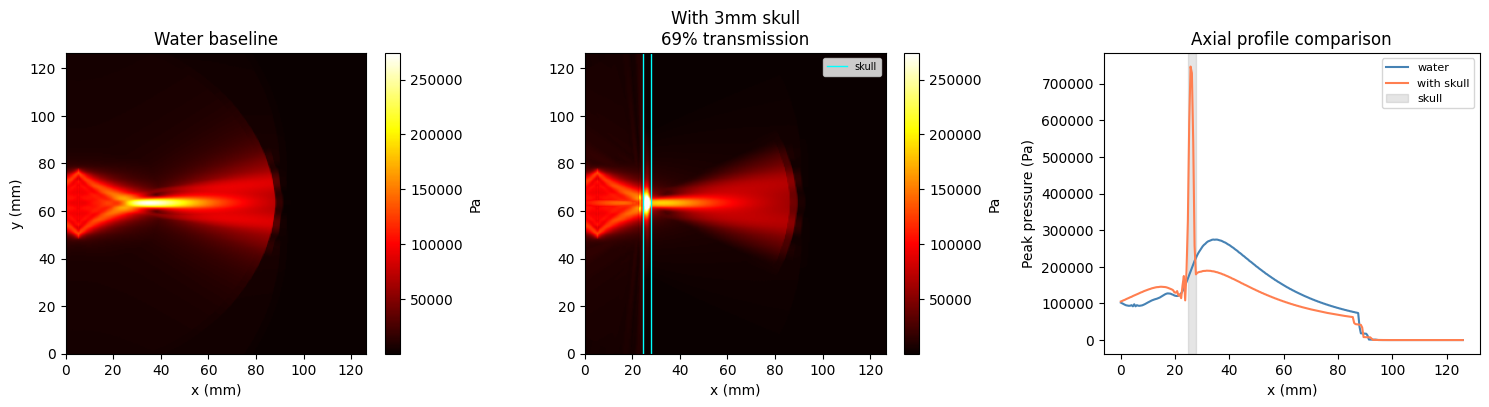

Saved to 04_skull_layer.png


: 

In [ ]:
# --- Parameters ---
freq         = 500e3
c0           = 1482.0
rho0         = 1000.0
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10

wavelength = c0 / freq
dx = wavelength / 6

Nx, Ny = 256, 256

# --- Skull properties (Mueller et al.) ---
c_skull   = 2900.0
rho_skull = 1900.0

# Build grid using skull speed for stable dt
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_skull, cfl=0.3)
n_time = kgrid.Nt
print(f"dt={kgrid.dt:.2e}s, Nt={n_time}")

# --- Skull geometry ---
skull_thickness_mm = 3.0
skull_start_x = transducer_x + int(20e-3 / dx)
skull_end_x   = skull_start_x + int(skull_thickness_mm * 1e-3 / dx)
print(f"Skull: x={skull_start_x*dx*1e3:.1f}mm to {skull_end_x*dx*1e3:.1f}mm")

# --- Heterogeneous medium (NO attenuation map — keep it simple first) ---
sound_speed_map = np.ones((Nx, Ny), dtype=float) * c0
density_map     = np.ones((Nx, Ny), dtype=float) * rho0
sound_speed_map[skull_start_x:skull_end_x, :] = c_skull
density_map[skull_start_x:skull_end_x, :]     = rho_skull

medium = kWaveMedium(
    sound_speed=sound_speed_map,
    density=density_map,
)

# --- Source ---
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources    = len(source_y_indices)

focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)
focal_point_y = center_y

burst = tone_burst(1/kgrid.dt, freq, 5).flatten()
print(f"Burst length: {len(burst)} samples")

delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
    kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), n_time)
    source_signals[i, d:end] = burst[:end-d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# --- Run with skull ---
print("Running with skull...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor)
p_max_skull = sensor_data['p_max'].reshape(Nx, Ny)

# Check for NaN
if np.isnan(p_max_skull).any():
    print("WARNING: NaN detected in skull simulation")
else:
    print(f"Skull sim OK — max pressure: {np.nanmax(p_max_skull)/1e3:.1f} kPa")

# --- Run water baseline ---
medium_water = kWaveMedium(sound_speed=c0, density=rho0)
print("Running water baseline...")
sensor_data_water = kspaceFirstOrder(kgrid, medium_water, source, sensor)
p_max_water = sensor_data_water['p_max'].reshape(Nx, Ny)
print(f"Water sim OK — max pressure: {np.max(p_max_water)/1e3:.1f} kPa")

# --- Results ---
# Only measure in post-skull region to avoid reflection artifacts
post_skull_water = p_max_water[skull_end_x:, :]
post_skull_skull = p_max_skull[skull_end_x:, :]

peak_water = np.max(post_skull_water)
peak_skull = np.max(post_skull_skull)
transmission = peak_skull / peak_water * 100

print(f"\n=== SKULL VALIDATION ===")
print(f"Peak pressure (water, post-skull):      {peak_water/1e3:.1f} kPa")
print(f"Peak pressure (with skull, post-skull): {peak_skull/1e3:.1f} kPa")
print(f"Transmission:               {transmission:.1f}%")
print(f"Pressure loss:              {100-transmission:.1f}%")
print(f"Mueller et al. expected:    ~65% transmission (35% loss)")

# --- Reflection coefficient check ---
Z_water = rho0 * c0
Z_skull = rho_skull * c_skull
R = ((Z_skull - Z_water) / (Z_skull + Z_water))**2
T_theoretical = 1 - R
print(f"\nTheoretical transmission (impedance only): {T_theoretical*100:.1f}%")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = np.max(p_max_water)

ax = axes[0]
im = ax.imshow(p_max_water.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot', vmax=vmax)
ax.set_title('Water baseline')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
plt.colorbar(im, ax=ax, label='Pa')

ax = axes[1]
im = ax.imshow(p_max_skull.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot', vmax=vmax)
ax.axvline(x=skull_start_x*dx*1e3, color='cyan', lw=1)
ax.axvline(x=skull_end_x*dx*1e3,   color='cyan', lw=1, label='skull')
ax.set_title(f'With 3mm skull\n{transmission:.0f}% transmission')
ax.set_xlabel('x (mm)')
ax.legend(fontsize=7)
plt.colorbar(im, ax=ax, label='Pa')

ax = axes[2]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max_water[:, center_y], label='water', color='steelblue')
ax.plot(x_mm, p_max_skull[:, center_y], label='with skull', color='coral')
ax.axvspan(skull_start_x*dx*1e3, skull_end_x*dx*1e3,
           alpha=0.2, color='gray', label='skull')
ax.set_xlabel('x (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile comparison')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('04_skull_layer.png', dpi=150)
plt.show()
print("Saved to 04_skull_layer.png")

# Skull Setups

### 05_circular_skull_setup
Reusable geometry: water coupling outside → circular skull ring → brain interior. No sources placed here — add them in subsequent test cells.

> **Note:** The exterior is water (c=1482, ρ=1000), not air. In real TUS the transducer always sits in a water coupling bath against the skull — there is no bare air-skull interface. Using air causes a density ratio of ~1570:1 at the bone boundary which overflows k-Wave's pseudospectral FFT solver regardless of CFL setting.

dx = 0.494 mm
Brain radius : 40.0 mm  (81.0 px)
Skull outer  : 45.0 mm  (91.1 px)
Grid edge    : 63.2 mm from centre

kgrid: dt=1.70e-08 s,  Nt=3621


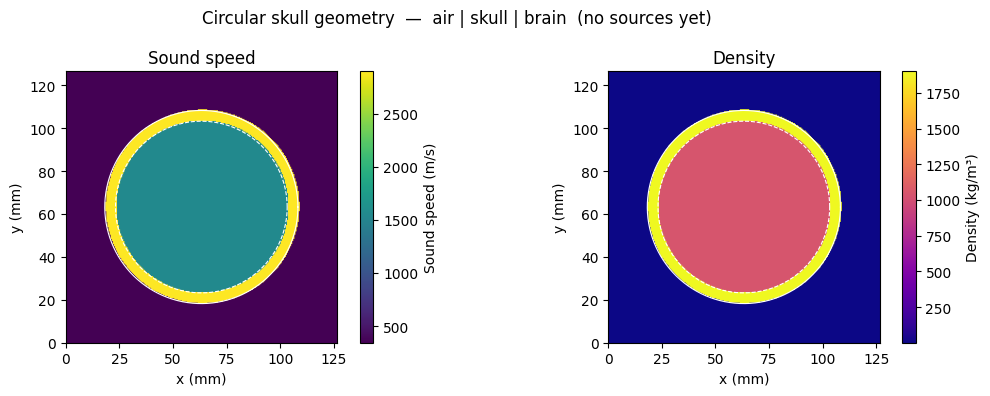

In [5]:
# ── Acoustic properties ──────────────────────────────────────────────────────
# Exterior = air: the device is mounted directly on the skull in-vivo (monkey).
# There is no water bath.  The transducer elements will be placed at the skull
# outer surface so the air medium never enters the acoustic propagation path.
c_air    = 343.0;    rho_air    = 1.21     # air (exterior / ambient)
c_skull  = 2900.0;   rho_skull  = 1900.0   # cortical bone (Mueller et al.)
c_brain  = 1560.0;   rho_brain  = 1040.0   # brain tissue

# ── Grid ─────────────────────────────────────────────────────────────────────
freq = 500e3
c0   = 1482.0          # water — used only for wavelength/dx sizing
wavelength = c0 / freq # ~3 mm
dx = wavelength / 6    # ~0.494 mm per grid point

Nx, Ny = 256, 256      # physical size ≈ 126 mm × 126 mm
cx, cy = Nx // 2, Ny // 2  # skull centre (grid indices)

# ── Skull geometry ────────────────────────────────────────────────────────────
brain_radius_mm    = 40.0   # inner radius of skull (brain surface)
skull_thickness_mm =  5.0   # skull wall thickness

skull_inner_px = brain_radius_mm                        * 1e-3 / dx
skull_outer_px = (brain_radius_mm + skull_thickness_mm) * 1e-3 / dx

print(f"dx = {dx*1e3:.3f} mm")
print(f"Brain radius : {brain_radius_mm:.1f} mm  ({skull_inner_px:.1f} px)")
print(f"Skull outer  : {brain_radius_mm + skull_thickness_mm:.1f} mm  ({skull_outer_px:.1f} px)")
print(f"Grid edge    : {Nx//2 * dx*1e3:.1f} mm from centre")

# ── Build radial distance map ─────────────────────────────────────────────────
XX, YY = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R = np.sqrt((XX - cx)**2 + (YY - cy)**2)

# ── Assign material properties ────────────────────────────────────────────────
sound_speed_map = np.full((Nx, Ny), c_air,   dtype=float)
density_map     = np.full((Nx, Ny), rho_air, dtype=float)

skull_mask = (R >= skull_inner_px) & (R < skull_outer_px)
brain_mask =  R <  skull_inner_px

sound_speed_map[skull_mask] = c_skull;  density_map[skull_mask] = rho_skull
sound_speed_map[brain_mask] = c_brain;  density_map[brain_mask] = rho_brain

# ── kWave grid and medium ─────────────────────────────────────────────────────
# CFL=0.1: skull/air density contrast ~1570:1 requires a tighter CFL for
# spectral-method stability.
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_skull, cfl=0.1)

medium = kWaveMedium(
    sound_speed=sound_speed_map,
    density=density_map,
)

print(f"\nkgrid: dt={kgrid.dt:.2e} s,  Nt={kgrid.Nt}")

# ── Visualise geometry ────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta  = np.linspace(0, 2*np.pi, 360)
cx_mm, cy_mm = cx*dx*1e3, cy*dx*1e3
r_inner_mm   = skull_inner_px * dx * 1e3
r_outer_mm   = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
im = ax.imshow(sound_speed_map.T, origin='lower', extent=extent, cmap='viridis')
plt.colorbar(im, ax=ax, label='Sound speed (m/s)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta), 'w--', lw=0.8)
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta), 'w-',  lw=0.8)
ax.set_title('Sound speed'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')

ax = axes[1]
im = ax.imshow(density_map.T, origin='lower', extent=extent, cmap='plasma')
plt.colorbar(im, ax=ax, label='Density (kg/m³)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta), 'w--', lw=0.8)
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta), 'w-',  lw=0.8)
ax.set_title('Density'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')

plt.suptitle('Circular skull geometry  —  air | skull | brain  (no sources yet)')
plt.tight_layout()
plt.savefig('05_circular_skull_setup.png', dpi=150)
plt.show()

### 06_centre_source
Single point source at the skull centre, 500 kHz 5-cycle burst — same signal as earlier tests. Uses the geometry from 05.

Running simulation...


k-Wave: 100%|██████████| 3621/3621 [02:15<00:00, 26.78step/s]


Done — max pressure: 71.3 kPa


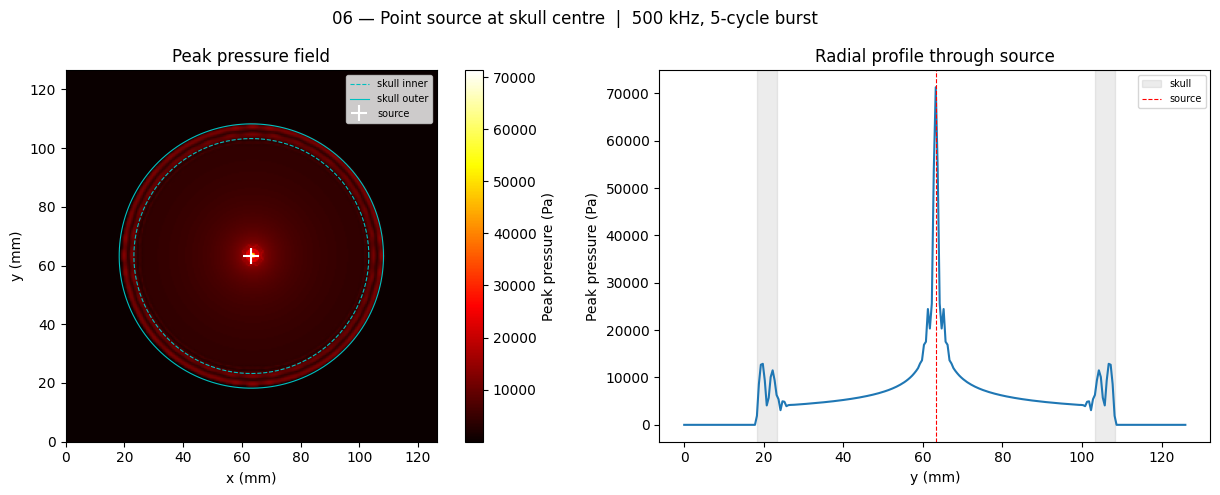

In [3]:
# Requires cell 05 to have been run first (kgrid, medium, cx, cy, dx, Nx, Ny,
# skull_inner_px, skull_outer_px, freq all come from there)

# ── Source: single point at skull centre ──────────────────────────────────────
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[cx, cy] = 1
source.p = burst * 1e5   # 100 kPa, matching earlier tests

# ── Sensor: full field, record peak pressure ──────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor)
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
cx_mm  = cx * dx * 1e3
cy_mm  = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3   # brain surface radius in mm
r_outer_mm = skull_outer_px * dx * 1e3   # outer skull radius in mm

theta = np.linspace(0, 2*np.pi, 360)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 2D peak-pressure field
ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(cx_mm, cy_mm, 'w+', ms=12, mew=1.5, label='source')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

# Right: radial profile through centre
ax = axes[1]
radial = p_max[cx, :]                  # slice along y through source
y_mm   = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, radial)
ax.axvspan(cy_mm - r_outer_mm, cy_mm - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cy_mm + r_inner_mm, cy_mm + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=cy_mm, color='red', lw=0.8, linestyle='--', label='source')
ax.set_xlabel('y (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Radial profile through source')
ax.legend(fontsize=7)

plt.suptitle('06 — Point source at skull centre  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('06_centre_source.png', dpi=150)
plt.show()

### 07_external_focus
Phased linear array placed outside the skull, aimed at the brain centre. Time delays computed from straight-line distance to target (refraction ignored for this first pass — goal is to see where the wave actually lands and by how much it shifts).

Target       : (63.2, 63.2) mm
n_sources    : 60  (aperture 30 mm on skull surface)
Element x range: 37 – 42 px  (18.3 – 20.7 mm)
Max delay    : 0.16 µs  (9 steps)

Running simulation...


k-Wave: 100%|██████████| 3621/3621 [03:34<00:00, 16.88step/s]


Done — global max pressure: 45.4 kPa

=== FOCUS REPORT ===
Target  : (63.2, 63.2) mm
Actual  : (58.3, 63.2) mm
Error   : 4.9 mm
Peak P  : 28.1 kPa  (in brain)


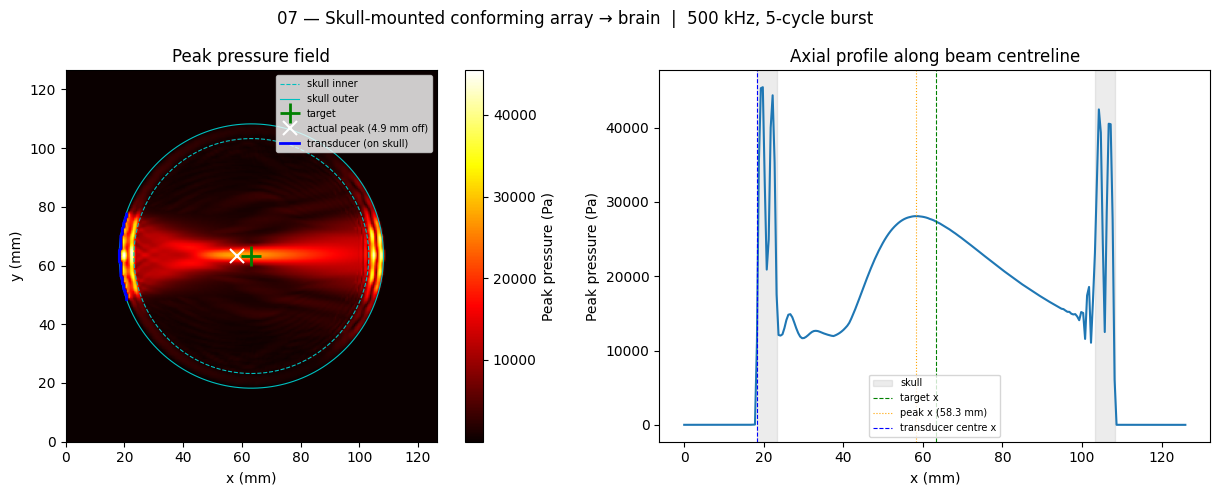

In [6]:
# Requires cell 05 to have been run first.
#
# Transducer model: conforming array mounted directly on the skull outer surface.
# Each element is placed at its corresponding point on the skull outer circle so
# there is no air gap and the source drives bone directly.  Delays are computed
# through skull + brain only (no air/water coupling segment).

# ── Target point ──────────────────────────────────────────────────────────────
target_x = cx               # aim at brain centre (change to steer)
target_y = cy

# ── Conforming array: elements placed on the skull outer surface ───────────────
# For each element at vertical position y_i, its x position on the left skull arc:
#   x_i = cx - floor( sqrt(skull_outer_px^2 - (y_i - cy)^2) )
# floor() puts the point just inside skull material.
aperture_mm  = 30.0
half_ap_px   = int((aperture_mm / 2) * 1e-3 / dx)
candidate_ys = np.arange(cy - half_ap_px, cy + half_ap_px)

src_x, src_y = [], []
for y_i in candidate_ys:
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:          # within the skull circle's y-extent
        x_i = cx - int(np.sqrt(skull_outer_px**2 - dy**2))
        src_x.append(x_i)
        src_y.append(int(y_i))

src_x     = np.array(src_x)
src_y     = np.array(src_y)
n_sources = len(src_x)

print(f"Target       : ({target_x*dx*1e3:.1f}, {target_y*dx*1e3:.1f}) mm")
print(f"n_sources    : {n_sources}  (aperture {aperture_mm:.0f} mm on skull surface)")
print(f"Element x range: {src_x.min()} – {src_x.max()} px  "
      f"({src_x.min()*dx*1e3:.1f} – {src_x.max()*dx*1e3:.1f} mm)")

# ── Multi-medium travel-time delays: skull → brain ────────────────────────────
# Source is at the skull outer surface; path = skull segment + brain segment.
# Find the skull/brain boundary by intersecting each ray with the inner circle.

def _ray_circle_t(ox, oy, ux, uy, R):
    """
    Parametric distance t (m) where unit-ray from (ox, oy) first enters a
    circle of radius R at the origin.  Returns (t_entry, t_exit) or (None, None).
    """
    b    = 2.0 * (ox * ux + oy * uy)
    c    = ox * ox + oy * oy - R * R
    disc = b * b - 4.0 * c
    if disc < 0.0:
        return None, None
    sq = np.sqrt(disc)
    return (-b - sq) / 2.0, (-b + sq) / 2.0

R_inner_m = skull_inner_px * dx   # brain surface radius (m)

travel_times = np.zeros(n_sources)
for i in range(n_sources):
    xi, yi = src_x[i], src_y[i]
    vec_x  = (target_x - xi) * dx
    vec_y  = (target_y - yi) * dx
    dist_m = np.sqrt(vec_x**2 + vec_y**2)
    ux, uy = vec_x / dist_m, vec_y / dist_m

    # Ray origin relative to skull centre
    ox = (xi - cx) * dx
    oy = (yi - cy) * dx

    t_br_in, _ = _ray_circle_t(ox, oy, ux, uy, R_inner_m)

    if t_br_in is None or t_br_in < 0:
        travel_times[i] = dist_m / c_brain           # fallback
    else:
        travel_times[i] = (t_br_in          / c_skull +   # through skull
                           (dist_m - t_br_in) / c_brain)  # through brain

delays_s = travel_times.max() - travel_times         # centre element fires last
max_delay_steps = int(delays_s.max() / kgrid.dt)
print(f"Max delay    : {delays_s.max()*1e6:.2f} µs  ({max_delay_steps} steps)")

# ── Source signals ────────────────────────────────────────────────────────────
burst  = tone_burst(1/kgrid.dt, freq, 5).flatten()
n_time = max_delay_steps + len(burst) + 200
if n_time > kgrid.Nt:
    kgrid.t_array = np.arange(n_time) * kgrid.dt

source_signals = np.zeros((n_sources, kgrid.Nt))
for i in range(n_sources):
    d   = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), kgrid.Nt)
    source_signals[i, d:end] = burst[:end - d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    source.p_mask[xi, yi] = 1
source.p = source_signals

# ── Sensor ────────────────────────────────────────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor)
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — global max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Find peak inside brain ────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa  (in brain)")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta  = np.linspace(0, 2*np.pi, 360)
cx_mm, cy_mm = cx*dx*1e3, cy*dx*1e3
r_inner_mm   = skull_inner_px * dx * 1e3
r_outer_mm   = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm + r_inner_mm*np.cos(theta), cy_mm + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm + r_outer_mm*np.cos(theta), cy_mm + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
# Draw transducer arc on skull surface
ax.plot(src_x * dx * 1e3, src_y * dx * 1e3, 'b-', lw=2, label='transducer (on skull)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm - r_outer_mm, cx_mm - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm + r_inner_mm, cx_mm + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.axvline(x=src_x[n_sources//2]*dx*1e3, color='blue', lw=0.8, linestyle='--',
           label='transducer centre x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('07 — Skull-mounted conforming array → brain  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('07_external_focus.png', dpi=150)
plt.show()

### 08_fermat_focus
Same skull-mounted conforming array as cell 07, but delays computed via **Fermat's principle** rather than straight-line distances. For each element the crossing point on the skull-brain boundary is numerically optimised so that `d_skull/c_skull + d_brain/c_brain` is minimised — this automatically satisfies Snell's law and removes the ~5 mm near-shift caused by skull-brain refraction.

In [ ]:
# Requires cell 05 to have been run first.
#
# Delays use Fermat's principle: for each element, the crossing point on the
# skull-brain boundary is optimised to minimise skull_path/c_skull + brain_path/c_brain.
# This satisfies Snell's law at the boundary and corrects the near-shift that
# straight-ray delays produce.

from scipy.optimize import minimize_scalar

# ── Target point ──────────────────────────────────────────────────────────────
target_x = cx               # brain centre — change to steer
target_y = cy

# ── Conforming array on skull outer surface ───────────────────────────────────
aperture_mm  = 30.0
half_ap_px   = int((aperture_mm / 2) * 1e-3 / dx)
candidate_ys = np.arange(cy - half_ap_px, cy + half_ap_px)

src_x, src_y = [], []
for y_i in candidate_ys:
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        x_i = cx - int(np.sqrt(skull_outer_px**2 - dy**2))
        src_x.append(x_i)
        src_y.append(int(y_i))

src_x     = np.array(src_x)
src_y     = np.array(src_y)
n_sources = len(src_x)

print(f"Target       : ({target_x*dx*1e3:.1f}, {target_y*dx*1e3:.1f}) mm")
print(f"n_sources    : {n_sources}")

# ── Fermat-optimal delays ─────────────────────────────────────────────────────
cx_m      = cx * dx
cy_m      = cy * dx
R_inner_m = skull_inner_px * dx

travel_times = np.zeros(n_sources)
for i in range(n_sources):
    xi_m = src_x[i] * dx
    yi_m = src_y[i] * dx
    tx_m = target_x * dx
    ty_m = target_y * dx

    phi_elem = np.arctan2(yi_m - cy_m, xi_m - cx_m)

    def time_fn(phi):
        Px = cx_m + R_inner_m * np.cos(phi)
        Py = cy_m + R_inner_m * np.sin(phi)
        return (np.sqrt((xi_m - Px)**2 + (yi_m - Py)**2) / c_skull +
                np.sqrt((tx_m - Px)**2 + (ty_m - Py)**2) / c_brain)

    res = minimize_scalar(time_fn,
                          bounds=(phi_elem - np.pi / 2, phi_elem + np.pi / 2),
                          method='bounded')
    travel_times[i] = res.fun

delays_s = travel_times.max() - travel_times
max_delay_steps = int(delays_s.max() / kgrid.dt)
print(f"Max delay    : {delays_s.max()*1e6:.2f} µs  ({max_delay_steps} steps)")

# ── Source signals ────────────────────────────────────────────────────────────
burst  = tone_burst(1/kgrid.dt, freq, 5).flatten()
n_time = max_delay_steps + len(burst) + 200
if n_time > kgrid.Nt:
    kgrid.t_array = np.arange(n_time) * kgrid.dt

source_signals = np.zeros((n_sources, kgrid.Nt))
for i in range(n_sources):
    d   = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), kgrid.Nt)
    source_signals[i, d:end] = burst[:end - d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    source.p_mask[xi, yi] = 1
source.p = source_signals

# ── Sensor ────────────────────────────────────────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor)
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — global max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Find peak inside brain ────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa  (in brain)")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
ax.plot(src_x * dx * 1e3, src_y * dx * 1e3, 'b-', lw=2, label='transducer (on skull)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.axvline(x=src_x[n_sources//2]*dx*1e3, color='blue', lw=0.8, linestyle='--',
           label='transducer centre x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('08 — Skull-mounted conforming array → brain  |  500 kHz  |  Fermat delays')
plt.tight_layout()
plt.savefig('08_fermat_focus.png', dpi=150)
plt.show()

### 09_time_reversal
Two-step time-reversal focus. **Step 1 (forward):** place a point source at the target, run the simulation, record the pressure time-series at every transducer element. **Step 2 (backward):** flip those recordings in time and replay them as source signals. The time-reversed signals carry exactly the phase correction needed to focus at the target — they account for refraction, impedance-mismatch reflections, and all other propagation effects automatically, without any analytical delay model.

Transducer elements: 60  (aperture 30 mm on skull surface)
Step 1: forward simulation (target → elements)…


k-Wave: 100%|██████████| 3621/3621 [01:58<00:00, 30.55step/s]


  Recorded: (60, 3621)  (elements × time steps)
Step 2: backward simulation (time-reversed focus)…


k-Wave: 100%|██████████| 3621/3621 [03:00<00:00, 20.01step/s]


Done — global max: 0.0 kPa

=== FOCUS REPORT ===
Target  : (63.2, 63.2) mm
Actual  : (58.8, 63.2) mm
Error   : 4.4 mm
Peak P  : 0.0 kPa


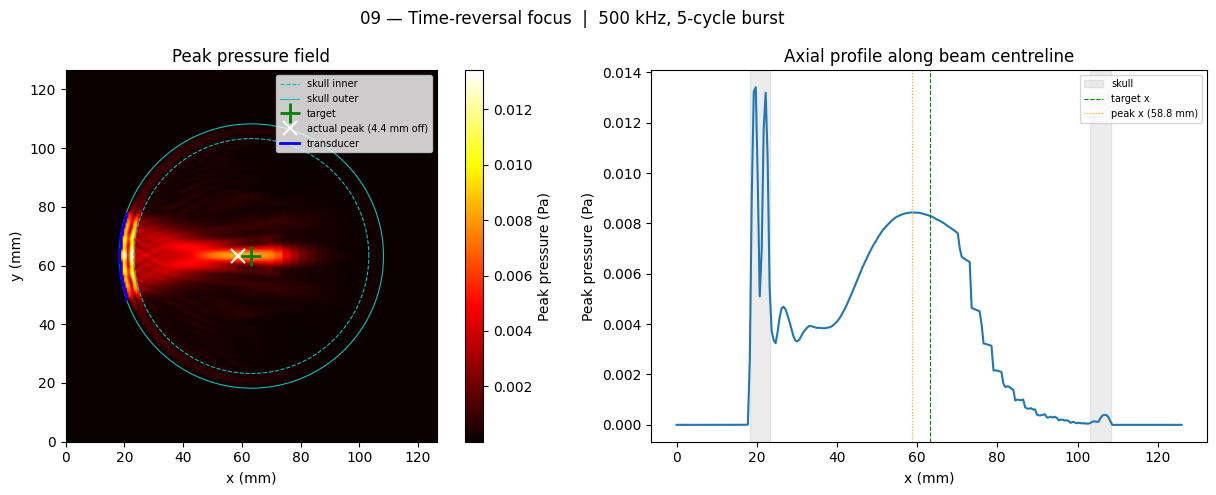

In [8]:
# Requires cell 05 to have been run first.
#
# Time-reversal focusing — two simulations:
#   1. Forward:  point source at target → record pressure at each transducer element
#   2. Backward: time-reversed recordings → focus pressure back at the target

# ── Target ────────────────────────────────────────────────────────────────────
target_x = cx
target_y = cy

# ── Conforming array (same geometry as cells 07/08) ───────────────────────────
aperture_mm = 30.0
half_ap_px  = int((aperture_mm / 2) * 1e-3 / dx)

src_x, src_y = [], []
for y_i in np.arange(cy - half_ap_px, cy + half_ap_px):
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        src_x.append(cx - int(np.sqrt(skull_outer_px**2 - dy**2)))
        src_y.append(int(y_i))
src_x = np.array(src_x)
src_y = np.array(src_y)
n_elem = len(src_x)
print(f"Transducer elements: {n_elem}  (aperture {aperture_mm:.0f} mm on skull surface)")

# ── Build element mask (used for both forward sensor and backward source) ──────
elem_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    elem_mask[xi, yi] = 1

# ── Step 1: Forward simulation — point source at target ───────────────────────
src_fwd       = kSource()
src_fwd.p_mask = np.zeros((Nx, Ny))
src_fwd.p_mask[target_x, target_y] = 1
src_fwd.p     = tone_burst(1/kgrid.dt, freq, 5).flatten()

sen_fwd        = kSensor()
sen_fwd.mask   = elem_mask.copy()
sen_fwd.record = ['p']          # full time-series at every element

print("Step 1: forward simulation (target → elements)…")
data_fwd = kspaceFirstOrder(kgrid, medium, src_fwd, sen_fwd)
p_at_elements = data_fwd['p']   # shape: (n_elem, Nt)
print(f"  Recorded: {p_at_elements.shape}  (elements × time steps)")

# ── Step 2: Backward simulation — time-reversed signals ───────────────────────
p_reversed = p_at_elements[:, ::-1]   # flip each element's signal in time

src_bwd        = kSource()
src_bwd.p_mask = elem_mask.copy()
src_bwd.p      = p_reversed

sen_bwd        = kSensor()
sen_bwd.mask   = np.ones((Nx, Ny))
sen_bwd.record = ['p_max']

print("Step 2: backward simulation (time-reversed focus)…")
data_bwd = kspaceFirstOrder(kgrid, medium, src_bwd, sen_bwd)
p_max = data_bwd['p_max'].reshape(Nx, Ny)
print(f"Done — global max: {np.max(p_max)/1e3:.1f} kPa")

# ── Focus report ──────────────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
ax.plot(src_x*dx*1e3, src_y*dx*1e3, 'b-', lw=2, label='transducer')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('09 — Time-reversal focus  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('09_time_reversal.png', dpi=150)
plt.show()